In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [14]:
sub_merged = pd.read_excel("../../data/processed/team/subway_merged_base.xlsx")
sub_merged['TOTAL_W'] = sub_merged['ES'] + sub_merged['EV']*4
sub_merged.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)

In [15]:
# 시설부하지수 상위 20% 역
priorities = pd.read_csv("../../data/processed/team/priority_area.csv", encoding='cp949')
priorities.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)
priorities.head()

,지하철역,호선명,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,종로5가,1,1410815,488319,34.61,3,0,3,40693.25
1,청량리,1,1319724,561989,42.58,2,6,8,40142.07
2,제기동,1,1013099,559716,55.25,3,2,5,39979.71
3,미아사거리,4,1544727,380795,24.65,2,2,4,38079.50
4,상계,4,1096973,261592,23.85,1,4,5,32699.00


In [16]:
transfer = pd.read_excel("../../data/processed/team/transfer_merged_final.xlsx")
transfer_master = pd.merge(sub_merged, transfer[['지하철역', '호선', '환승노선', '환승거리', '환승소요시간']], on='지하철역', how='left')
transfer_master = transfer_master.sort_values(by='환승거리', ascending=False)
transfer_master.loc[transfer_master['지하철역']=='서울역', '지하철역'] = '서울'
transfer_master = transfer_master[~(transfer_master['지하철역']=='지축')]

In [17]:
transfer_station_list = transfer_master[transfer_master['호선명'].str.contains(",")]  #이렇게 하면 창동역이 빠짐
transfer_station_list = transfer_station_list['지하철역'].unique()
transfer_station_list

array(['고속터미널', '종로3가', '노원', '대림', '동작', '신당', '동대문역사문화공원', '충정로', '동대문',
       '잠실', '연신내', '이수', '신설동', '삼각지', '을지로3가', '약수', '영등포구청', '김포공항',
       '당산', '청구', '시청', '불광', '동묘앞', '왕십리', '합정', '을지로4가', '건대입구', '군자',
       '교대', '사당', '공덕', '여의도', '오금', '태릉입구', '천호', '가락시장', '충무로', '서울'],
      dtype=object)

In [18]:
# 집중관리역에 포함되는 환승역 몇개인지? 
common_station = transfer_station_list[pd.Series(transfer_station_list).isin(priorities['지하철역'])]
common_station

array(['종로3가', '동대문', '잠실', '연신내', '을지로3가', '교대', '사당', '천호', '서울'],
      dtype=object)

In [19]:
transfer = pd.read_excel("../../data/processed/team/transfer_merged_final.xlsx")

In [20]:
transfer['TOTAL_W'] = transfer['ES'] + transfer['EV']*4
transfer['시설효율성'] = (transfer['환승거리'] / transfer['TOTAL_W']).round(2)
transfer['시설부하지수'] = (transfer['무임승하차'].str.replace(",", "").astype('Int64') / transfer['TOTAL_W']).round(2)
transfer.columns

Index(['호선명', '지하철역', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차',
       '무임승하차비중', 'ES', 'EV', 'MW', 'WL', 'TOTAL', '호선', '환승노선', '환승거리',
       '환승소요시간', 'TOTAL_W', '시설효율성', '시설부하지수'],
      dtype='object')

In [21]:
transfer = transfer[['호선명', '지하철역','전체승하차', '무임승하차','무임승하차비중', 'ES', 'EV', 'MW', 'WL', 'TOTAL', '호선', '환승노선', '환승거리', '환승소요시간', 'TOTAL_W', '시설효율성', '시설부하지수']]
transfer

,호선명,지하철역,전체승하차,무임승하차,무임승하차비중,ES,EV,MW,WL,TOTAL,호선,환승노선,환승거리,환승소요시간,TOTAL_W,시설효율성,시설부하지수
0,"3,7,9",고속터미널,5041958,745834,14.79,77,10,4,4,95,7.0,9호선,314.0,04:22,117,2.68,6374.65
1,"1,3,5",종로3가,3088248,901715,29.20,20,7,2,0,29,1.0,5호선,312.0,04:20,48,6.50,18785.73
2,"4,7",노원,2677934,532429,19.88,25,7,0,0,32,4.0,7호선,278.0,03:52,53,5.25,10045.83
3,"2,7",대림,1991465,368397,18.50,19,7,0,1,27,2.0,7호선,276.0,03:50,47,5.87,7838.23
4,"4,9",동작,213077,57987,27.21,21,9,2,0,32,4.0,9호선,245.0,03:24,57,4.30,1017.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,9,신방화,400608,99937,24.95,22,4,0,0,26,NaN,NaN,NaN,NaN,38,NaN,2629.92
248,9,양천향교,582088,98776,16.97,27,4,0,0,31,NaN,NaN,NaN,NaN,43,NaN,2297.12
249,9,염창,1004681,159211,15.85,12,4,0,0,16,NaN,NaN,NaN,NaN,28,NaN,5686.11
250,9,증미,428833,77371,18.04,18,3,0,0,21,NaN,NaN,NaN,NaN,30,NaN,2579.03


[]

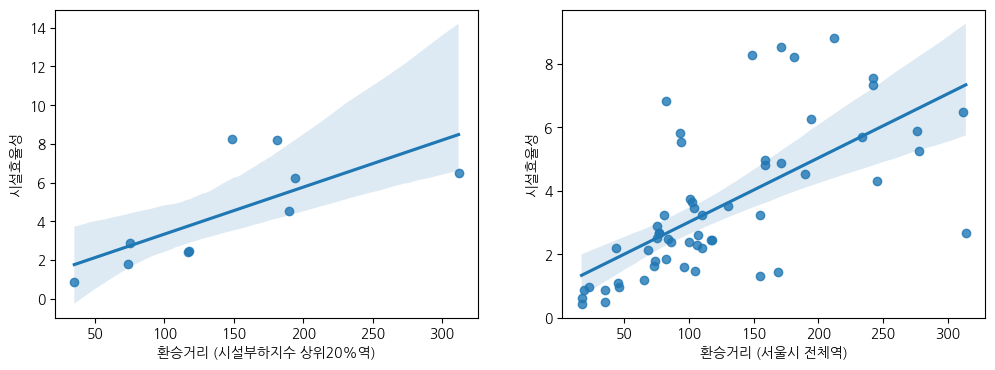

In [22]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.regplot(data=transfer[transfer['지하철역'].isin(common_station)], x='환승거리', y='시설효율성', ax=axes[0])
sns.regplot(data=transfer, x='환승거리', y='시설효율성', ax=axes[1])
axes[0].set_xlabel("환승거리 (시설부하지수 상위20%역)")
axes[1].set_xlabel("환승거리 (서울시 전체역)")
plt.plot()